# Capítulo 4: Series de Tiempo. Caso de Estudio 1: Clima

> Dora María Ballesteros  
> Primera edición, 2026  
> ISBN: 978-1-957395-63-0  
> 🔗 **[Consultar el libro en Editorial REDIPE](https://editorial.redipe.org/index.php/1/catalog/book/245)**

**Versión:** Septiembre de 2026

---

## Material complementario del libro

Este notebook acompaña el **Capítulo 4** del libro *Investigación en Ciencia de Datos* y desarrolla el **Caso de Estudio 1: Clima**, con énfasis en el **Análisis Exploratorio de Datos (EDA) aplicado a Series de Tiempo**.

A partir de un conjunto de variables climáticas registradas temporalmente, se estudiarán tres aspectos fundamentales:

- La **evolución de las variables a lo largo del tiempo**.
- La **dependencia entre diferentes series de tiempo**.
- La **dependencia entre los valores actuales y los valores pasados de una misma serie**.

Esta versión se concentra exclusivamente en el **EDA temporal**. El *Feature Engineering* y el modelamiento serán desarrollados posteriormente.

# **1. Lectura y previsualización del dataset**


In [1]:
import pandas as pd
clima_df = pd.read_csv("/content/clima.csv")
clima_df.head()

,tiempo_hora_local,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,estado_clima
0,01-10-2019 00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,partly-cloudy-night
1,01-10-2019 01:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,partly-cloudy-night
2,01-10-2019 02:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,partly-cloudy-night
3,01-10-2019 03:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,partly-cloudy-night
4,01-10-2019 04:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,partly-cloudy-night


In [2]:
# Información general del dataset
clima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tiempo_hora_local         499 non-null    object 
 1   temperatura               499 non-null    float64
 2   humedad                   499 non-null    float64
 3   punto_rocio               499 non-null    float64
 4   direccion_viento          499 non-null    float64
 5   velocidad_viento          499 non-null    float64
 6   rafagas_viento            499 non-null    float64
 7   presion                   499 non-null    float64
 8   indice_UV                 499 non-null    float64
 9   ozono                     499 non-null    float64
 10  intensidad_precipitacion  499 non-null    float64
 11  estado_clima              499 non-null    object 
dtypes: float64(10), object(2)
memory usage: 60.9+ KB


In [3]:
# Dimensiones del dataset
print("Cantidad de filas:", clima_df.shape[0])
print("Cantidad de columnas:", clima_df.shape[1])

Cantidad de filas: 648
Cantidad de columnas: 12


In [4]:
# Revisión de datos nulos
clima_df.isnull().sum()

,0
tiempo_hora_local,149
temperatura,149
humedad,149
punto_rocio,149
direccion_viento,149
velocidad_viento,149
rafagas_viento,149
presion,149
indice_UV,149
ozono,149


# **2. Preparación de los datos**

In [5]:
# Eliminar filas completamente vacías
clima_df = clima_df.dropna(how='all')

Es necesario transformar la columna tiempo_hora_local dado que es de tipo object y no de *datetime*

In [6]:
# Conversión de la variable temporal
clima_df['tiempo_hora_local'] = pd.to_datetime(clima_df['tiempo_hora_local'], dayfirst=True)

# Ordenamiento cronológico
clima_df = clima_df.sort_values('tiempo_hora_local')

In [7]:
clima_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499 entries, 0 to 498
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   tiempo_hora_local         499 non-null    datetime64[ns]
 1   temperatura               499 non-null    float64       
 2   humedad                   499 non-null    float64       
 3   punto_rocio               499 non-null    float64       
 4   direccion_viento          499 non-null    float64       
 5   velocidad_viento          499 non-null    float64       
 6   rafagas_viento            499 non-null    float64       
 7   presion                   499 non-null    float64       
 8   indice_UV                 499 non-null    float64       
 9   ozono                     499 non-null    float64       
 10  intensidad_precipitacion  499 non-null    float64       
 11  estado_clima              499 non-null    object        
dtypes: datetime64[ns](1), float

In [8]:
# Definir la variable temporal como índice (deja de ser una columna del dataset)
clima_df = clima_df.set_index('tiempo_hora_local')

clima_df.head()

,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,estado_clima
tiempo_hora_local,,,,,,,,,,,
2019-10-01 00:00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,partly-cloudy-night
2019-10-01 01:00:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,partly-cloudy-night
2019-10-01 02:00:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,partly-cloudy-night
2019-10-01 03:00:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,partly-cloudy-night
2019-10-01 04:00:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,partly-cloudy-night


# **3. EDA: Análisis Exploratorio de los Datos**

**3.1 Estructura temporal del dataset → periodo, frecuencia, continuidad, duplicados**


Antes de analizar el comportamiento de las variables, se revisa la estructura temporal del conjunto de datos: periodo de observación, frecuencia de muestreo, continuidad temporal y posibles registros duplicados.

In [9]:
# Periodo de observación
print("Fecha inicial:", clima_df.index.min())
print("Fecha final:", clima_df.index.max())
print("Número de observaciones:", len(clima_df))

Fecha inicial: 2019-10-01 00:00:00
Fecha final: 2019-10-21 18:00:00
Número de observaciones: 499


In [10]:
# Frecuencia temporal observada
clima_df.index.to_series().diff().value_counts()

,count
tiempo_hora_local,
0 days 01:00:00,498


In [11]:
# Verificación de registros temporales duplicados
print("Fechas duplicadas:", clima_df.index.duplicated().sum())

Fechas duplicadas: 0


In [12]:
# Verificación de continuidad temporal
rango_esperado = pd.date_range(
    start=clima_df.index.min(),
    end=clima_df.index.max(),
    freq='h'
)

fechas_faltantes = rango_esperado.difference(clima_df.index)

print("Fechas faltantes:", len(fechas_faltantes))

Fechas faltantes: 0


> 💡 **Nota sobre continuidad temporal**
>
> La continuidad de una serie de tiempo **no significa necesariamente que debamos tener observaciones para todos los instantes del calendario**. Esto depende de la **frecuencia y del calendario esperados para el fenómeno que estamos analizando**.
>
> En nuestro caso, las variables climáticas se registran cada hora y esperamos que el monitoreo sea continuo. Por esta razón, si falta una hora, podemos considerarla una observación faltante.
>
> Sin embargo, pensemos en otro ejemplo. En una serie de **bolsa de valores** no esperamos encontrar observaciones durante los periodos en los que el mercado está cerrado, como fines de semana, días festivos o determinadas horas del día. En este caso, esos intervalos no representan necesariamente datos faltantes.
>
> **Antes de buscar fechas faltantes, primero debemos preguntarnos cómo y cuándo esperamos observar el fenómeno.**

**3.2 Evolución temporal y Análisis de tendencia de las series**



In [13]:
# Seleccionar las variables numéricas
variables_numericas = clima_df.select_dtypes(include='number').columns

variables_numericas

Index(['temperatura', 'humedad', 'punto_rocio', 'direccion_viento',
       'velocidad_viento', 'rafagas_viento', 'presion', 'indice_UV', 'ozono',
       'intensidad_precipitacion'],
      dtype='object')

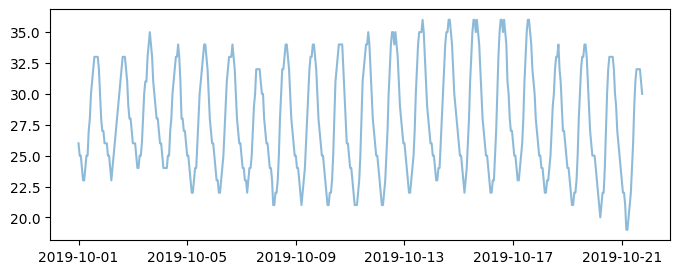

In [14]:
# Seleccionamos una de las variables numéricas (Serie) a graficar
import matplotlib.pyplot as plt
serie = clima_df['temperatura']

plt.figure(figsize=(8, 3))
plt.plot(clima_df.index, serie,
         label='Serie observada', alpha=0.5)

Esta gráfica representa la evolución temporal de la Serie, pero aún no incluye su tendencia, para ello necesitamos aplicar una media móvil.

### **Media móvil**

> Para observar la tendencia de una serie podemos utilizar una **media móvil**, que calcula el promedio de las observaciones contenidas en una **ventana** que se desplaza a lo largo del tiempo.
>
> En `Pandas` utilizamos:
>
> `rolling(window=...)`
>
> donde `window` indica la **cantidad de observaciones incluidas**. Como tenemos una observación cada hora, `window=24` corresponde a **24 horas** y `window=72` a **72 horas**.
>

> 💡 **Rolling durante el EDA**
>
> En esta etapa utilizamos la media móvil únicamente para **visualizar la tendencia de la serie**. Por esta razón, empleamos `center=True`, de manera que la ventana quede centrada alrededor del instante que estamos observando.
>
> En este caso, la ventana puede incluir observaciones anteriores y posteriores al instante analizado, lo cual es válido porque **todavía no estamos construyendo features para entrenar un modelo**.
>
> Más adelante, durante **Feature Engineering**, el cálculo deberá realizarse utilizando únicamente información del pasado para evitar **data leakage**.

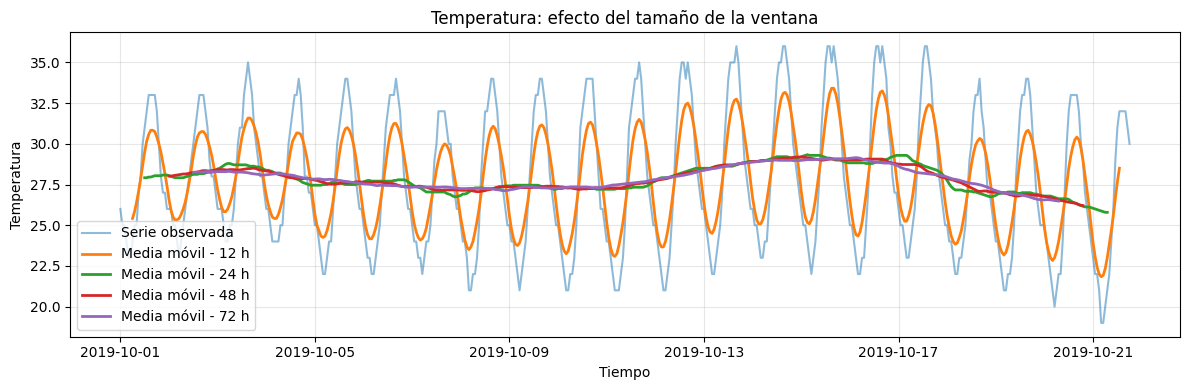

In [15]:
# Tendencia para la Serie Temperatura

serie = clima_df['temperatura']

media_12h = serie.rolling(
    window=12,
    center=True
).mean()

media_24h = serie.rolling(
    window=24,
    center=True
).mean()

media_48h = serie.rolling(
    window=48,
    center=True
).mean()

media_72h = serie.rolling(
    window=72,
    center=True
).mean()

plt.figure(figsize=(12, 4))

plt.plot(clima_df.index, serie,
         label='Serie observada', alpha=0.5)

plt.plot(clima_df.index, media_12h,
         linewidth=2, label='Media móvil - 12 h')

plt.plot(clima_df.index, media_24h,
         linewidth=2, label='Media móvil - 24 h')

plt.plot(clima_df.index, media_48h,
         linewidth=2, label='Media móvil - 48 h')

plt.plot(clima_df.index, media_72h,
         linewidth=2, label='Media móvil - 72 h')

plt.title('Temperatura: efecto del tamaño de la ventana')
plt.xlabel('Tiempo')
plt.ylabel('Temperatura')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

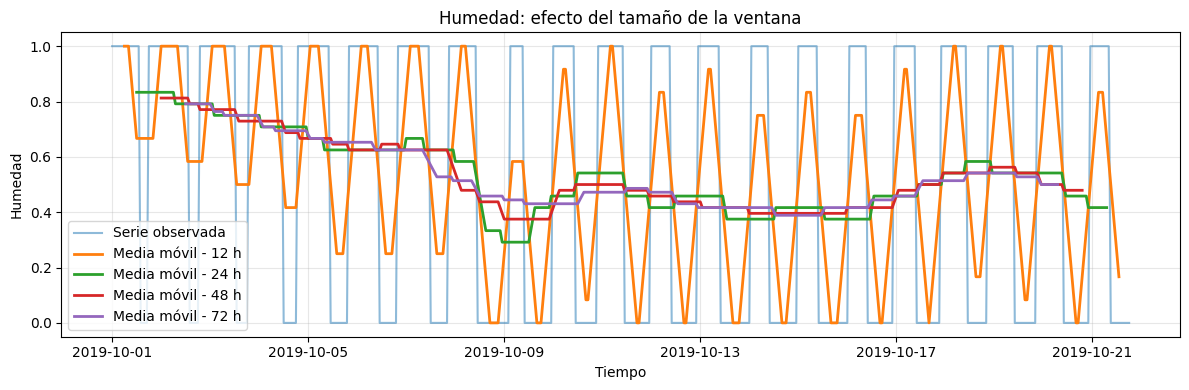

In [16]:
# Tendencia para la serie Humedad

serie = clima_df['humedad']

media_12h = serie.rolling(
    window=12,
    center=True
).mean()

media_24h = serie.rolling(
    window=24,
    center=True
).mean()

media_48h = serie.rolling(
    window=48,
    center=True
).mean()

media_72h = serie.rolling(
    window=72,
    center=True
).mean()

plt.figure(figsize=(12, 4))

plt.plot(clima_df.index, serie,
         label='Serie observada', alpha=0.5)

plt.plot(clima_df.index, media_12h,
         linewidth=2, label='Media móvil - 12 h')

plt.plot(clima_df.index, media_24h,
         linewidth=2, label='Media móvil - 24 h')

plt.plot(clima_df.index, media_48h,
         linewidth=2, label='Media móvil - 48 h')

plt.plot(clima_df.index, media_72h,
         linewidth=2, label='Media móvil - 72 h')

plt.title('Humedad: efecto del tamaño de la ventana')
plt.xlabel('Tiempo')
plt.ylabel('Humedad')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

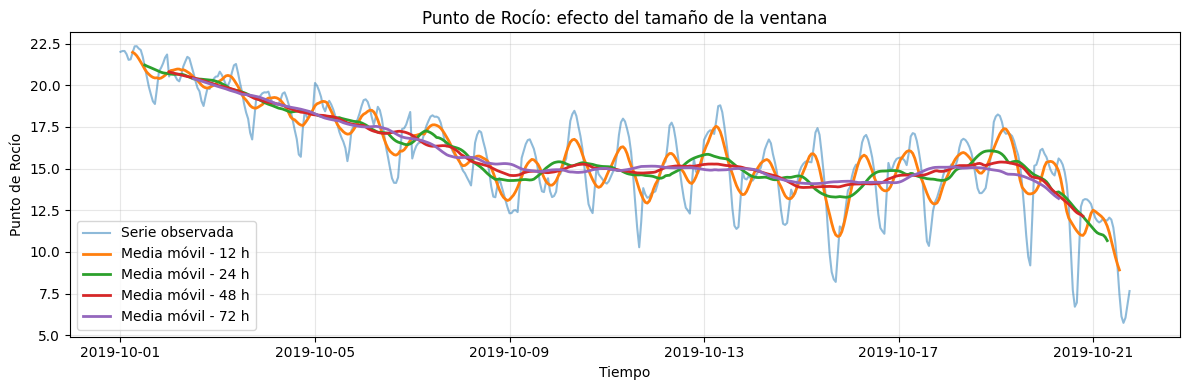

In [17]:
# Tendencia para la serie Punto de Rocío

serie = clima_df['punto_rocio']

media_12h = serie.rolling(
    window=12,
    center=True
).mean()

media_24h = serie.rolling(
    window=24,
    center=True
).mean()

media_48h = serie.rolling(
    window=48,
    center=True
).mean()

media_72h = serie.rolling(
    window=72,
    center=True
).mean()

plt.figure(figsize=(12, 4))

plt.plot(clima_df.index, serie,
         label='Serie observada', alpha=0.5)

plt.plot(clima_df.index, media_12h,
         linewidth=2, label='Media móvil - 12 h')

plt.plot(clima_df.index, media_24h,
         linewidth=2, label='Media móvil - 24 h')

plt.plot(clima_df.index, media_48h,
         linewidth=2, label='Media móvil - 48 h')

plt.plot(clima_df.index, media_72h,
         linewidth=2, label='Media móvil - 72 h')

plt.title('Punto de Rocío: efecto del tamaño de la ventana')
plt.xlabel('Tiempo')
plt.ylabel('Punto de Rocío')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

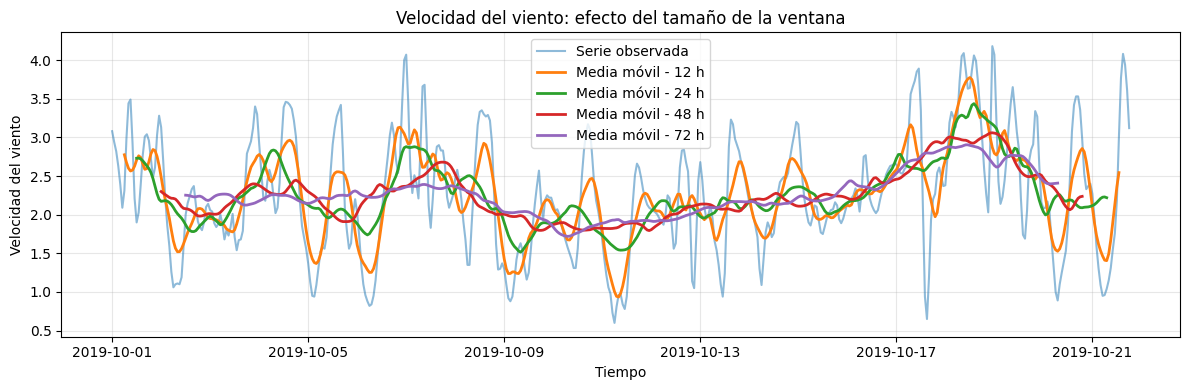

In [18]:
# Tendencia para la serie Velocidad del viento

serie = clima_df['velocidad_viento']

media_12h = serie.rolling(
    window=12,
    center=True
).mean()

media_24h = serie.rolling(
    window=24,
    center=True
).mean()

media_48h = serie.rolling(
    window=48,
    center=True
).mean()

media_72h = serie.rolling(
    window=72,
    center=True
).mean()

plt.figure(figsize=(12, 4))

plt.plot(clima_df.index, serie,
         label='Serie observada', alpha=0.5)

plt.plot(clima_df.index, media_12h,
         linewidth=2, label='Media móvil - 12 h')

plt.plot(clima_df.index, media_24h,
         linewidth=2, label='Media móvil - 24 h')

plt.plot(clima_df.index, media_48h,
         linewidth=2, label='Media móvil - 48 h')

plt.plot(clima_df.index, media_72h,
         linewidth=2, label='Media móvil - 72 h')

plt.title('Velocidad del viento: efecto del tamaño de la ventana')
plt.xlabel('Tiempo')
plt.ylabel('Velocidad del viento')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

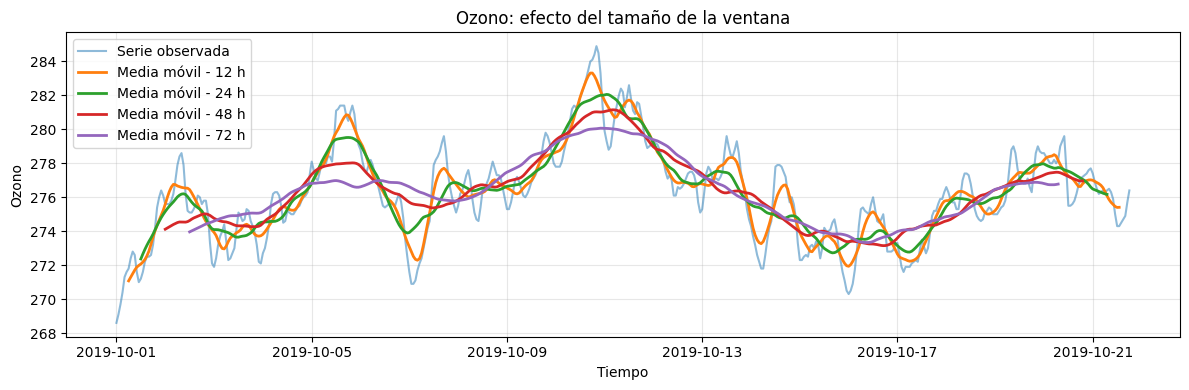

In [19]:
# Tendencia para serie Ozono

serie = clima_df['ozono']


media_12h = serie.rolling(
    window=12,
    center=True
).mean()

media_24h = serie.rolling(
    window=24,
    center=True
).mean()

media_48h = serie.rolling(
    window=48,
    center=True
).mean()

media_72h = serie.rolling(
    window=72,
    center=True
).mean()

plt.figure(figsize=(12, 4))

plt.plot(clima_df.index, serie,
         label='Serie observada', alpha=0.5)

plt.plot(clima_df.index, media_12h,
         linewidth=2, label='Media móvil - 12 h')

plt.plot(clima_df.index, media_24h,
         linewidth=2, label='Media móvil - 24 h')

plt.plot(clima_df.index, media_48h,
         linewidth=2, label='Media móvil - 48 h')

plt.plot(clima_df.index, media_72h,
         linewidth=2, label='Media móvil - 72 h')

plt.title('Ozono: efecto del tamaño de la ventana')
plt.xlabel('Tiempo')
plt.ylabel('Ozono')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

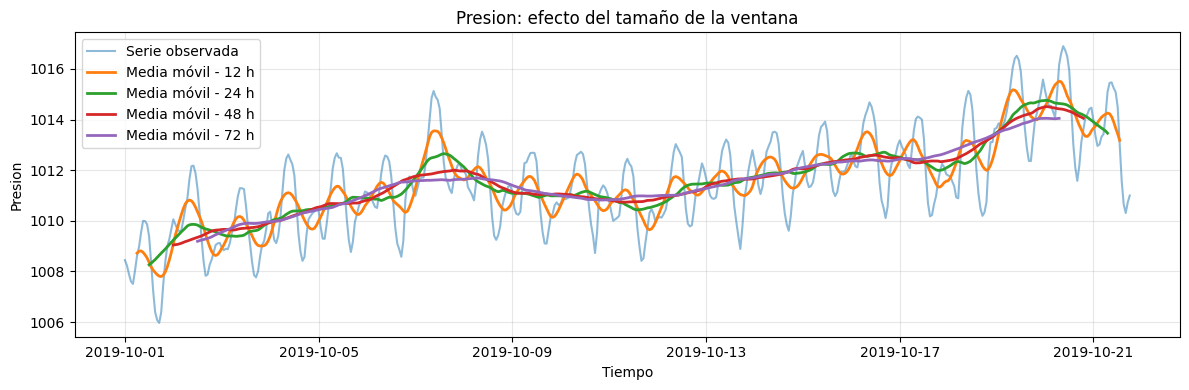

In [20]:
# Tendencia para serie Presion

serie = clima_df['presion']

media_12h = serie.rolling(
    window=12,
    center=True
).mean()

media_24h = serie.rolling(
    window=24,
    center=True
).mean()

media_48h = serie.rolling(
    window=48,
    center=True
).mean()

media_72h = serie.rolling(
    window=72,
    center=True
).mean()

plt.figure(figsize=(12, 4))

plt.plot(clima_df.index, serie,
         label='Serie observada', alpha=0.5)

plt.plot(clima_df.index, media_12h,
         linewidth=2, label='Media móvil - 12 h')

plt.plot(clima_df.index, media_24h,
         linewidth=2, label='Media móvil - 24 h')

plt.plot(clima_df.index, media_48h,
         linewidth=2, label='Media móvil - 48 h')

plt.plot(clima_df.index, media_72h,
         linewidth=2, label='Media móvil - 72 h')

plt.title('Presion: efecto del tamaño de la ventana')
plt.xlabel('Tiempo')
plt.ylabel('Presion')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

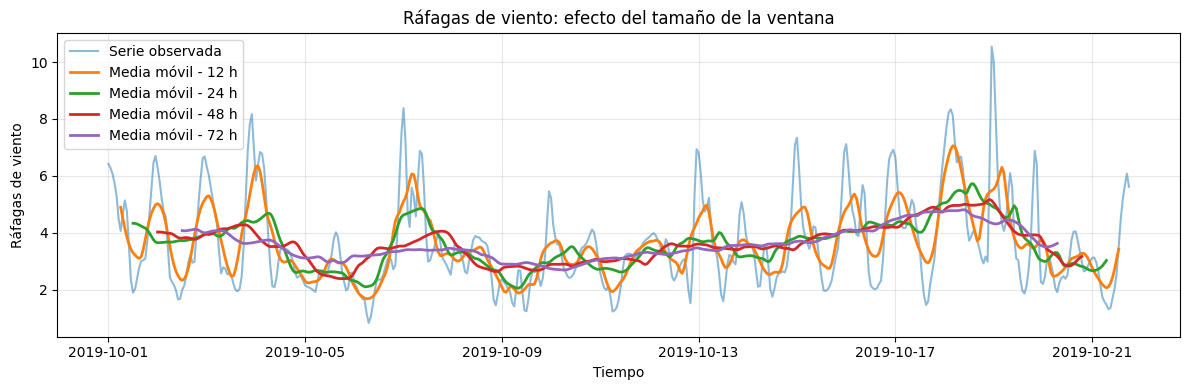

In [21]:
# Tendencia para serie Ráfagas de Viento

serie = clima_df['rafagas_viento']

media_12h = serie.rolling(
    window=12,
    center=True
).mean()

media_24h = serie.rolling(
    window=24,
    center=True
).mean()

media_48h = serie.rolling(
    window=48,
    center=True
).mean()

media_72h = serie.rolling(
    window=72,
    center=True
).mean()

plt.figure(figsize=(12, 4))

plt.plot(clima_df.index, serie,
         label='Serie observada', alpha=0.5)

plt.plot(clima_df.index, media_12h,
         linewidth=2, label='Media móvil - 12 h')

plt.plot(clima_df.index, media_24h,
         linewidth=2, label='Media móvil - 24 h')

plt.plot(clima_df.index, media_48h,
         linewidth=2, label='Media móvil - 48 h')

plt.plot(clima_df.index, media_72h,
         linewidth=2, label='Media móvil - 72 h')

plt.title('Ráfagas de viento: efecto del tamaño de la ventana')
plt.xlabel('Tiempo')
plt.ylabel('Ráfagas de viento')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**¿Qué patrones temporales observamos directamente en las series?**

**3.3 Dependencia entre diferentes series**


>Hasta ahora hemos analizado cómo evoluciona cada variable a lo largo del tiempo. Sin embargo, las variables climáticas no necesariamente se comportan de manera independiente.
>
>Por ejemplo, podríamos preguntarnos: **¿los cambios en la temperatura están relacionados con los cambios en la humedad? ¿Qué ocurre con la temperatura y la sensación térmica?**
>
>Una primera aproximación para estudiar estas relaciones consiste en calcular la **correlación** entre las diferentes series.
>
>El coeficiente de correlación permite medir la intensidad y dirección de una relación lineal entre dos variables:
>
>- Valores cercanos a **1** indican una relación lineal positiva fuerte.
>- Valores cercanos a **-1** indican una relación lineal negativa fuerte.
>- Valores cercanos a **0** indican una relación lineal débil o inexistente.
>
>💡 **Importante:** una correlación alta indica asociación entre dos variables, pero **no implica que una sea la causa de la otra**.

**Matriz de Correlación**

In [22]:
# Matriz de correlación
correlacion = clima_df.select_dtypes(include='number').corr()

correlacion.round(2)

,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion
temperatura,1.00,-0.78,-0.32,0.19,0.28,-0.24,-0.26,0.59,0.07,0.09
humedad,-0.78,1.00,0.54,-0.20,-0.19,0.25,0.09,-0.42,-0.18,0.06
punto_rocio,-0.32,0.54,1.00,-0.20,-0.09,0.16,-0.22,-0.07,-0.17,0.14
direccion_viento,0.19,-0.20,-0.20,1.00,0.13,-0.03,0.09,0.19,0.05,-0.02
velocidad_viento,0.28,-0.19,-0.09,0.13,1.00,0.62,-0.04,0.01,-0.21,0.04
rafagas_viento,-0.24,0.25,0.16,-0.03,0.62,1.00,0.00,-0.31,-0.35,-0.02
presion,-0.26,0.09,-0.22,0.09,-0.04,0.00,1.00,0.20,0.05,0.01
indice_UV,0.59,-0.42,-0.07,0.19,0.01,-0.31,0.20,1.00,0.08,0.12
ozono,0.07,-0.18,-0.17,0.05,-0.21,-0.35,0.05,0.08,1.00,-0.03
intensidad_precipitacion,0.09,0.06,0.14,-0.02,0.04,-0.02,0.01,0.12,-0.03,1.00


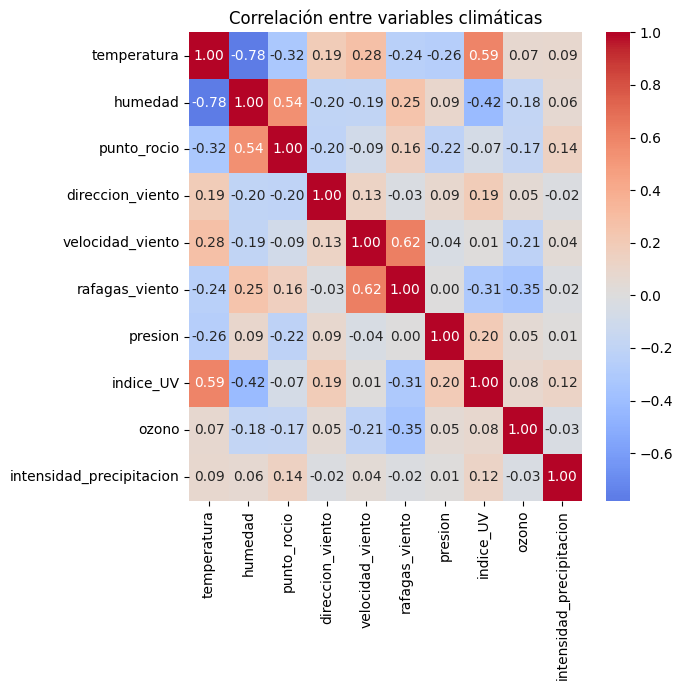

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlación entre variables climáticas')
plt.tight_layout()
plt.show()

>La matriz de correlación nos muestra varias relaciones llamativas. Para observar una de ellas con mayor detalle, seleccionamos una pareja de variables con una **correlación de -0.78**.
>
>¿Qué significa este valor? Que cuando una variable aumenta, la otra **tiende a disminuir**. Veamos esta relación directamente en los datos mediante un diagrama de dispersión.

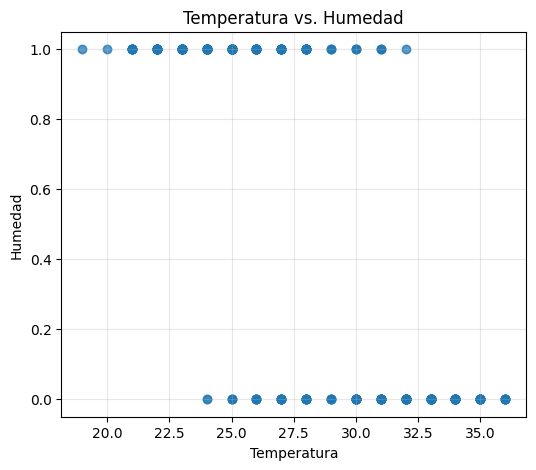

In [24]:
plt.figure(figsize=(6, 5))

plt.scatter(
    clima_df['temperatura'],
    clima_df['humedad'],
    alpha=0.5
)

plt.xlabel('Temperatura')
plt.ylabel('Humedad')
plt.title('Temperatura vs. Humedad')
plt.grid(alpha=0.3)

plt.show()

> Se puede observar que, para valores bajos y medios de temperatura, la humedad tiende a ser alta. Mientras que, para valores medios y altos de temperatura, la humedad tiende a ser baja.
>
> El valor de correlación no es exactamente **-1**, dado que algunos valores medios de temperatura pueden corresponder tanto con valores altos como bajos de humedad.

**3.4 Dependencia entre valores actuales y pasados**

> Hasta ahora hemos estudiado la relación entre diferentes variables. Sin embargo, cuando trabajamos con series de tiempo aparece otra pregunta importante:
>
>**¿El valor actual de una variable está relacionado con sus propios valores pasados?**
>
> Por ejemplo, si conocemos la temperatura de las horas anteriores, ¿esta información nos dice algo sobre la temperatura actual?
>
> Para estudiar esta dependencia utilizamos la **autocorrelación**, que mide la relación de una serie consigo misma cuando la desplazamos en el tiempo.
>
Cada desplazamiento se denomina **retardo o *lag***. Por ejemplo:

- `lag = 1`: relación entre el valor actual y el valor de **1 hora antes**.
- `lag = 6`: relación con el valor de **6 horas antes**.
- `lag = 24`: relación con el valor de **24 horas antes**.

En nuestro caso podemos interpretar los *lags* directamente en horas porque previamente verificamos que las observaciones están separadas regularmente por intervalos de una hora.

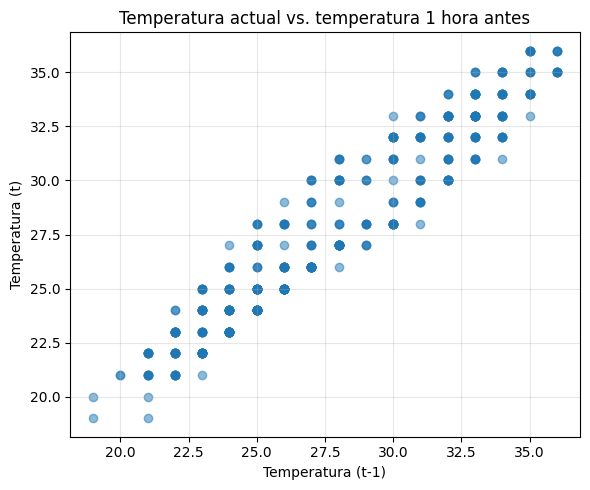

In [25]:
# Temperatura actual y temperatura una hora antes
temperatura_actual = clima_df['temperatura']
temperatura_lag1 = clima_df['temperatura'].shift(1)

plt.figure(figsize=(6, 5))

plt.scatter(
    temperatura_lag1,
    temperatura_actual,
    alpha=0.5
)

plt.xlabel('Temperatura (t-1)')
plt.ylabel('Temperatura (t)')
plt.title('Temperatura actual vs. temperatura 1 hora antes')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

> ¿Qué podemos observar? Los puntos se concentran alrededor de una diagonal: cuando la temperatura de la hora anterior es baja, la temperatura actual también tiende a ser baja; y cuando la temperatura anterior aumenta, la temperatura actual también tiende a aumentar.
>
> Esto nos muestra que la temperatura actual **no es independiente de su pasado**. En este caso, conocer la temperatura de una hora antes aporta información sobre la temperatura actual.

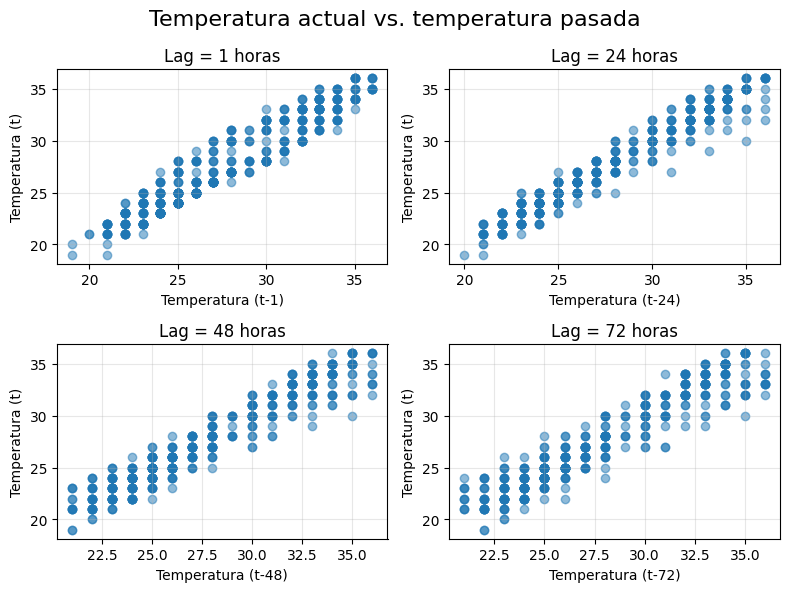

In [26]:
# Efecto del tamaño del lag

import matplotlib.pyplot as plt

temperatura_actual = clima_df['temperatura']

# Lags que queremos analizar
lags = [1, 24, 48, 72]

# Crear figura 2 x 2
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8, 6)
)

# Recorrer cada lag y cada subplot
for ax, lag in zip(axes.flatten(), lags):

    temperatura_pasada = clima_df['temperatura'].shift(lag)

    ax.scatter(
        temperatura_pasada,
        temperatura_actual,
        alpha=0.5
    )

    ax.set_xlabel(f'Temperatura (t-{lag})')
    ax.set_ylabel('Temperatura (t)')
    ax.set_title(f'Lag = {lag} horas')
    ax.grid(alpha=0.3)

plt.suptitle(
    'Temperatura actual vs. temperatura pasada',
    fontsize=16
)

plt.tight_layout()
plt.show()

> ¿Qué podemos observar? La temperatura actual presenta una relación fuerte con sus valores pasados, incluso cuando aumentamos el *lag* de **1 a 72 horas**.
>
> Sin embargo, a medida que nos alejamos del presente, los puntos tienden a presentar una mayor dispersión. Esto sugiere que la relación con el pasado se mantiene, pero **su intensidad puede cambiar dependiendo del retardo analizado**.
>
> Entonces surge una nueva pregunta: **¿tendríamos que construir una gráfica para cada posible *lag*?**

**No. Para eso tenemos la función de autocorrelación (ACF)**

**ACF**
>
> Las gráficas anteriores nos permitieron observar la relación entre la temperatura actual y algunos valores específicos de su pasado. Sin embargo, analizar cada *lag* por separado sería poco práctico.
>
> La **función de autocorrelación (ACF)** nos permite observar simultáneamente cómo cambia esta relación a medida que aumentamos el retardo.
>
> En la gráfica, cada *lag* representa cuántas observaciones desplazamos la serie hacia el pasado. Como nuestros datos son horarios, podemos interpretar directamente los *lags* en **horas**.

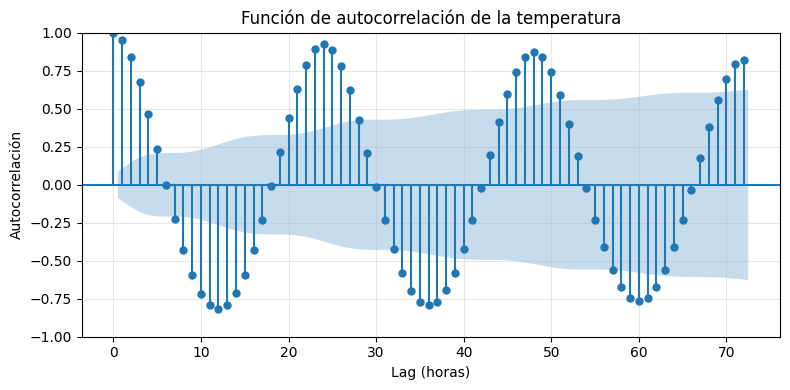

In [27]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Función de autocorrelación de la serie Temperatura
fig, ax = plt.subplots(figsize=(8, 4))

plot_acf(
    clima_df['temperatura'].dropna(),
    lags=72,
    ax=ax
)

ax.set_title('Función de autocorrelación de la temperatura')
ax.set_xlabel('Lag (horas)')
ax.set_ylabel('Autocorrelación')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Antes de analizar la gráfica, veamos qué información nos entrega.**
>
> Cada barra representa la **autocorrelación para un determinado *lag***. Como nuestros datos se registran cada hora, podemos interpretar directamente los *lags* en horas. Por ejemplo, `lag = 24` significa que estamos comparando la temperatura actual con la temperatura de **24 horas antes**.
>
> Los valores de autocorrelación pueden variar entre **-1 y 1**:
>
> - Valores cercanos a **1** indican una relación positiva fuerte.
> - Valores cercanos a **-1** indican una relación negativa fuerte.
> - Valores cercanos a **0** indican poca relación.
>
> ¿Y la zona sombreada? Representa un **intervalo de confianza del 95 %** alrededor de cero. Si una barra sobrepasa esta zona, tenemos evidencia de que la relación encontrada para ese *lag* es significativa.
>
> 💡 **Un detalle:** en `lag = 0` la autocorrelación siempre será igual a **1**, porque estamos comparando la serie consigo misma.



Ahora sí, observa la gráfica: **¿qué ocurre con la autocorrelación de la temperatura a medida que nos desplazamos hacia el pasado?**

> Se observa una **alta autocorrelación en retardos cercanos a múltiplos de 24 horas**, lo que evidencia el comportamiento cíclico diario de la temperatura.
>
> Sin embargo, a medida que nos alejamos en el tiempo, disminuye la cantidad de *lags* alrededor de cada múltiplo de 24 horas que presentan una autocorrelación alta y significativa. Esto indica que **el ciclo diario se mantiene, pero la dependencia con el pasado se va concentrando en retardos cada vez más específicos**.

**Podemos realizar el análisis anterior con otras series de tiempo**


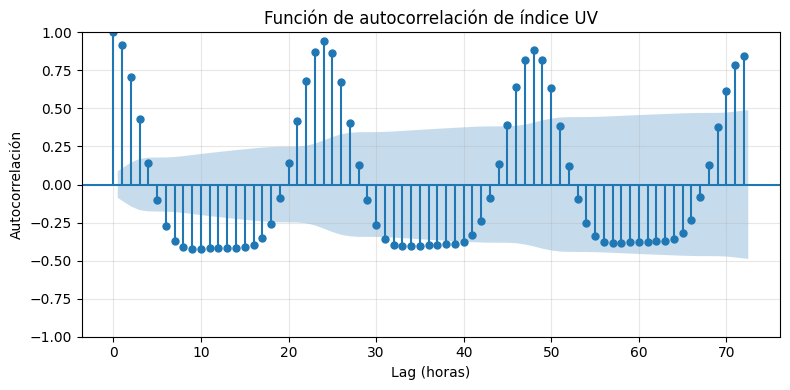

In [28]:
# Función de autocorrelación de la serie Índice UV
fig, ax = plt.subplots(figsize=(8, 4))

plot_acf(
    clima_df['indice_UV'].dropna(),
    lags=72,
    ax=ax
)

ax.set_title('Función de autocorrelación de índice UV')
ax.set_xlabel('Lag (horas)')
ax.set_ylabel('Autocorrelación')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

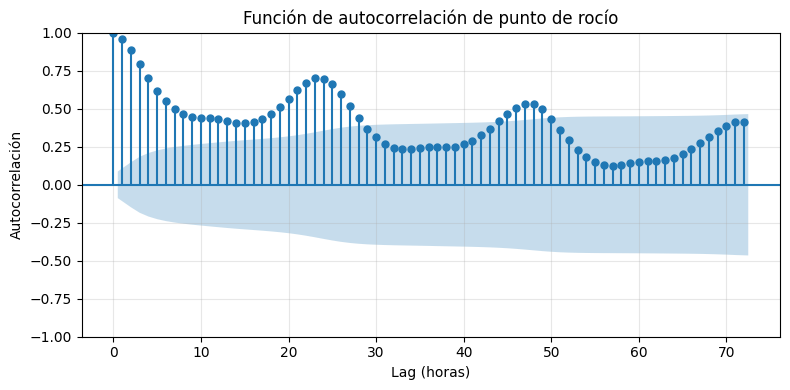

In [29]:
# Función de autocorrelación de la serie Punto de Rocío
fig, ax = plt.subplots(figsize=(8, 4))

plot_acf(
    clima_df['punto_rocio'].dropna(),
    lags=72,
    ax=ax
)

ax.set_title('Función de autocorrelación de punto de rocío')
ax.set_xlabel('Lag (horas)')
ax.set_ylabel('Autocorrelación')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

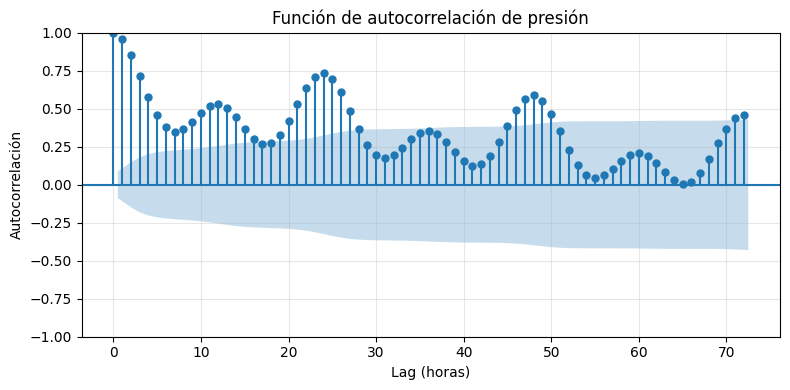

In [30]:
# Función de autocorrelación de la serie Presión
fig, ax = plt.subplots(figsize=(8, 4))

plot_acf(
    clima_df['presion'].dropna(),
    lags=72,
    ax=ax
)

ax.set_title('Función de autocorrelación de presión')
ax.set_xlabel('Lag (horas)')
ax.set_ylabel('Autocorrelación')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

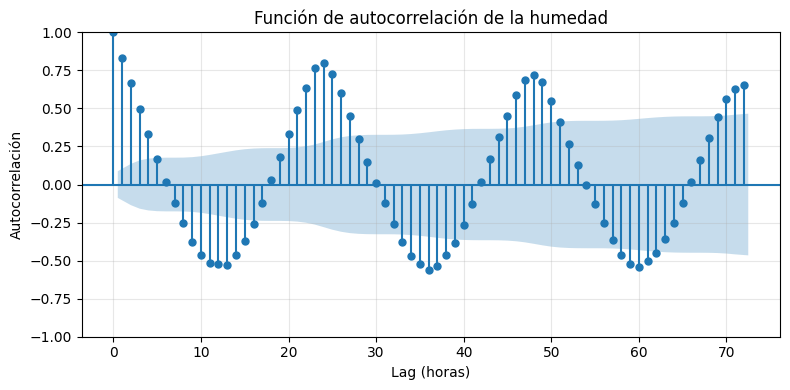

In [31]:
# Función de autocorrelación de la serie Humedad
fig, ax = plt.subplots(figsize=(8, 4))

plot_acf(
    clima_df['humedad'].dropna(),
    lags=72,
    ax=ax
)

ax.set_title('Función de autocorrelación de la humedad')
ax.set_xlabel('Lag (horas)')
ax.set_ylabel('Autocorrelación')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **4. Modelamiento antes de aplicar FE**

>´Antes de construir nuevos *features*, vamos a entrenar un primer modelo utilizando únicamente la información disponible originalmente en el dataset.
>
> ¿Por qué hacerlo ahora? Porque necesitamos un **punto de referencia** que nos permita comprobar, más adelante, si los nuevos *features* realmente aportan al modelo.
>
> Pero antes de entrenar aparece una pregunta importante: **¿podemos dividir una Serie de Tiempo aleatoriamente entre entrenamiento y prueba?**
>
> En este caso, no. Queremos utilizar el **pasado para aprender** y evaluar el modelo con datos que ocurren **después en el tiempo**.
>
> Por esta razón, conservaremos el orden temporal de las observaciones: las primeras serán utilizadas para entrenamiento y las más recientes para prueba.

**4.1 Definición de la variable objetivo**

En este caso queremos predecir el **estado del clima** a partir de las variables meteorológicas disponibles.

Antes de construir el modelo, veamos qué categorías tiene nuestra variable objetivo y cuántas observaciones tenemos de cada una.

In [32]:
# Categorías de la variable objetivo
clima_df['estado_clima'].value_counts()

,count
estado_clima,
clear-night,182
clear-day,159
partly-cloudy-night,64
partly-cloudy-day,64
cloudy,30


In [33]:
# Distribución porcentual de las clases
clima_df['estado_clima'].value_counts(normalize=True).mul(100).round(2)

,proportion
estado_clima,
clear-night,36.47
clear-day,31.86
partly-cloudy-night,12.83
partly-cloudy-day,12.83
cloudy,6.01


> ¿Qué podemos observar? Las clases no tienen la misma cantidad de observaciones. Los estados `clear-night` y `clear-day` representan la mayor parte de los datos, mientras que `cloudy` aparece con mucha menor frecuencia.
>
> Este desbalance será importante al momento de evaluar el modelo: **no será suficiente observar únicamente cuántas predicciones son correctas en total; también necesitaremos revisar qué tan bien reconoce cada estado del clima.**

**4.2 Codificación de la variable objetivo**

Nuestra variable objetivo, `estado_clima`, no es numérica, por lo que debemos aplicarle un tipo de transformación que **no cambie el significado de las clases**. Los números funcionan únicamente como etiquetas que permiten identificar cada categoría.

In [34]:
# Diccionario de codificación
clima_dict = {
    'clear-day': 1,
    'clear-night': 2,
    'partly-cloudy-day': 3,
    'partly-cloudy-night': 4,
    'cloudy': 5
}

# Codificación de la variable objetivo
clima_df['estado_clima_num'] = clima_df['estado_clima'].map(clima_dict)

# Verificación
clima_df[['estado_clima', 'estado_clima_num']].head()

,estado_clima,estado_clima_num
tiempo_hora_local,,
2019-10-01 00:00:00,partly-cloudy-night,4
2019-10-01 01:00:00,partly-cloudy-night,4
2019-10-01 02:00:00,partly-cloudy-night,4
2019-10-01 03:00:00,partly-cloudy-night,4
2019-10-01 04:00:00,partly-cloudy-night,4


> 👀 **Ojo:** aquí hemos utilizado valores numéricos (`1, 2, 3, 4, 5`) porque `estado_clima` es nuestra **variable objetivo** y los números funcionan únicamente como etiquetas para identificar cada clase. **No existe una jerarquía entre ellas**: `5` no significa más que `1`. Si `estado_clima` fuera un *feature* de entrada, esta codificación podría hacer que el modelo interpretara un orden que realmente no existe; en ese caso, utilizaríamos una codificación como **One-Hot Encoding**.

In [35]:
# Comprobamos que no quede ninguna categoría sin codificar
print(
    "Valores no codificados:",
    clima_df['estado_clima_num'].isna().sum()
)

Valores no codificados: 0


**4.3 Eliminar la variable categórica original (estado_clima)**

In [36]:
clima_df = clima_df.drop(columns=['estado_clima'])

clima_df.head()


,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,estado_clima_num
tiempo_hora_local,,,,,,,,,,,
2019-10-01 00:00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,4
2019-10-01 01:00:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,4
2019-10-01 02:00:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,4
2019-10-01 03:00:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,4
2019-10-01 04:00:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,4


**4.4 Separar entrada (X) y salida (y) del dataset y dividir los datos entre entrenamiento y validación interna**

In [37]:
# Variable objetivo
y = clima_df['estado_clima_num']

# Variables predictoras
X = clima_df.drop(columns=['estado_clima_num'])

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (499, 10)
Dimensión de y: (499,)


In [38]:
# Punto de corte: 70 % entrenamiento - 30 % prueba
punto_corte = int(len(clima_df) * 0.7)

# División temporal
X_train = X.iloc[:punto_corte]
X_test  = X.iloc[punto_corte:]

y_train = y.iloc[:punto_corte]
y_test  = y.iloc[punto_corte:]

print("Observaciones de entrenamiento:", len(X_train))
print("Observaciones de prueba:", len(X_test))

print("\nPeriodo de entrenamiento:")
print(X_train.index.min(), "a", X_train.index.max())

print("\nPeriodo de prueba:")
print(X_test.index.min(), "a", X_test.index.max())

Observaciones de entrenamiento: 349
Observaciones de prueba: 150

Periodo de entrenamiento:
2019-10-01 00:00:00 a 2019-10-15 12:00:00

Periodo de prueba:
2019-10-15 13:00:00 a 2019-10-21 18:00:00


**División de los datos**

> Como estamos trabajando con Series de Tiempo, **no vamos a mezclar aleatoriamente las observaciones**. Utilizaremos el primer 70 % de los datos para entrenamiento y el 30 % más reciente para prueba.
>
De esta manera, el modelo aprende utilizando información del **pasado** y lo evaluamos con observaciones que ocurren **posteriormente en el tiempo**.

**4.5 Entrenamiento del modelo baseline**

In [39]:
from sklearn.ensemble import RandomForestClassifier

# Modelo baseline
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenamiento
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [40]:
# Predicciones
y_pred = modelo.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print()

# Reporte por clase
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Accuracy: 0.66

              precision    recall  f1-score   support

           1       0.85      0.81      0.83        68
           2       0.63      0.79      0.70        56
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        23
           5       0.00      0.00      0.00         0

    accuracy                           0.66       150
   macro avg       0.29      0.32      0.31       150
weighted avg       0.62      0.66      0.64       150



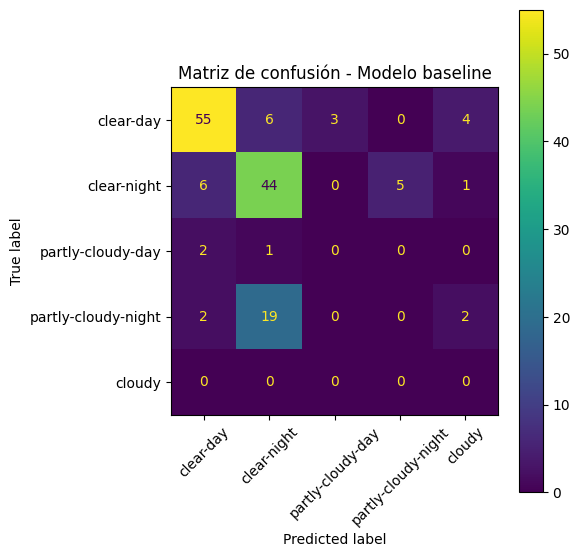

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[1, 2, 3, 4, 5]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'clear-day',
        'clear-night',
        'partly-cloudy-day',
        'partly-cloudy-night',
        'cloudy'
    ]
)

disp.plot(ax=ax, xticks_rotation=45)

plt.title('Matriz de confusión - Modelo baseline')
plt.tight_layout()
plt.show()

In [43]:
clima_df.to_csv("clima_eda.csv", index=True)